In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("email_spam_detection.csv")

In [3]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(7000, 9)


In [4]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   object 
 2   Subject            7000 non-null   object 
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 492.3+ KB
None

Statistical Summary:
           Email_ID Sender_Email    Subject  Email_Length    Num_Links  \
count   7000.000000         6999       7000   6959.000000  7000.000000   
unique          NaN         6973          8           NaN          NaN   
top             NaN            

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64


In [6]:
df["Sender_Email"] = df["Sender_Email"].replace(r'^\s*$', np.nan, regex=True)

print("\nMissing values after replacing blanks:")
print(df.isnull().sum())

# Fill missing Sender_Email with "Unknown"
df["Sender_Email"].fillna("Unknown", inplace=True)


Missing values after replacing blanks:
Email_ID              0
Sender_Email         28
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64


C:\Users\khush\AppData\Local\Temp\ipykernel_26908\3300144883.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sender_Email"].fillna("Unknown", inplace=True)


In [7]:
print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)


Duplicate Rows: 0
Shape after removing duplicates: (7000, 9)


In [8]:
print("\nData Types:")
print(df.dtypes)

# Convert columns if required
numeric_columns = [
    "Email_Length",
    "Num_Links",
    "Num_Special_Chars",
    "Capital_Words",
    "Has_Attachment",
    "Spam"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')



Data Types:
Email_ID               int64
Sender_Email          object
Subject               object
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object


In [9]:
print("\nRows with missing Email_Length:")
print(df[df["Email_Length"].isnull()])

print("\nRows with Num_Special_Chars = -1")
print(df[df["Num_Special_Chars"] == -1])

print("\nRows with Num_Links = 99")
print(df[df["Num_Links"] == 99])

# Replace invalid values with NaN
df.loc[df["Num_Special_Chars"] == -1, "Num_Special_Chars"] = np.nan
df.loc[df["Num_Links"] == 99, "Num_Links"] = np.nan


Rows with missing Email_Length:
      Email_ID          Sender_Email               Subject  Email_Length  \
0            1               Unknown               Meeting           NaN   
173        174   user173@outlook.com        Project Update           NaN   
346        347   user346@outlook.com             Greetings           NaN   
519        520     user519@gmail.com             Greetings           NaN   
692        693     user692@gmail.com               Meeting           NaN   
865        866     user865@gmail.com               Invoice           NaN   
1038      1039  user1038@company.com             Win Prize           NaN   
1211      1212  user1211@company.com  Account Verification           NaN   
1384      1385  user1384@outlook.com        Project Update           NaN   
1557      1558  user1557@outlook.com  Account Verification           NaN   
1730      1731  user1730@company.com             Greetings           NaN   
1903      1904  user1903@outlook.com             Greeti

In [10]:
df["Email_Length"].fillna(df["Email_Length"].median(), inplace=True)
df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median(), inplace=True)
df["Num_Links"].fillna(df["Num_Links"].median(), inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
dtype: int64


C:\Users\khush\AppData\Local\Temp\ipykernel_26908\1334463118.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Email_Length"].fillna(df["Email_Length"].median(), inplace=True)
C:\Users\khush\AppData\Local\Temp\ipykernel_26908\1334463118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

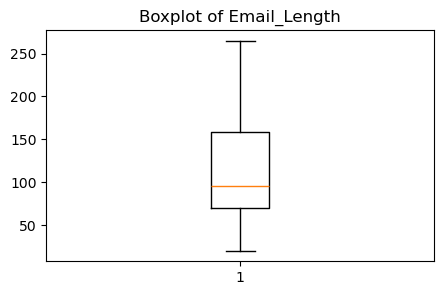

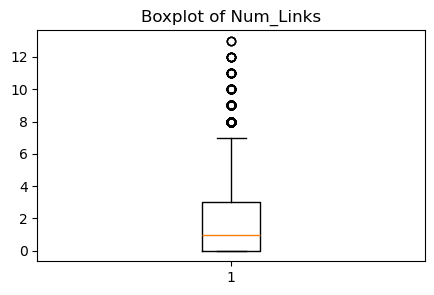

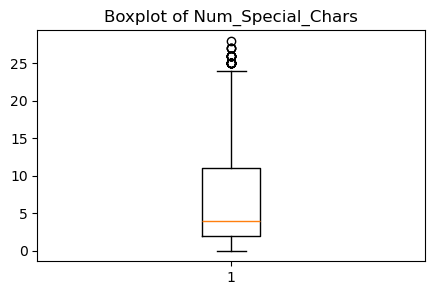


Email_Length
Number of Outliers: 0

Num_Links
Number of Outliers: 283

Num_Special_Chars
Number of Outliers: 26


In [11]:
columns = ["Email_Length", "Num_Links", "Num_Special_Chars"]

for col in columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# IQR Method
for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Number of Outliers:", len(outliers))


In [12]:
print("\nSpam Class Distribution:")
print(df["Spam"].value_counts())


Spam Class Distribution:
Spam
0    4864
1    2136
Name: count, dtype: int64


In [13]:
df.to_csv("email_spam_detection_cleaned.csv", index=False)

print("\nData Cleaning Completed Successfully!")
print("Cleaned dataset saved as 'email_spam_detection_cleaned.csv'")


Data Cleaning Completed Successfully!
Cleaned dataset saved as 'email_spam_detection_cleaned.csv'
